# 04 - Dissertation Figures and Tables

Generates the Chapter 4 figures and supporting tables from the outputs of Notebooks 01 to 03. It also computes the conditioning diagnostic reported in Table F.4. The separate `state_regime_diagnostics.json` described in Appendix G.4 is displayed only when present.

Figure numbers in this notebook are internal file labels. Dissertation Figure 3.1.1 is Figure_3_1, 4.2.1 is Figure_4_2, 4.3.1 is Figure_4_3, 4.3.2 is Figure_4_4, 4.4.1 is Figure_4_5, 4.4.3 is Figure_4_6, 4.4.4 is Figure_4_8 and 4.4.5 is Figure_4_9. Figure 4.4.2 is produced by Notebook 02.

## 1. Imports and paths

Loads the completed run and creates the dissertation figure folder.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support


def find_project_root() -> Path:
    """Find the repository root from the data/nsynth folder."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "data" / "nsynth").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find data/nsynth. Start Jupyter inside the repository."
    )


PROJECT_DIR = find_project_root()

LATEST_RUN_PATH = PROJECT_DIR / "results_final" / "latest_run.json"
if not LATEST_RUN_PATH.exists():
    raise FileNotFoundError("Run Notebook 02 before Notebook 04.")
with LATEST_RUN_PATH.open("r", encoding="utf-8") as f:
    RUN_TAG = json.load(f)["run_tag"]
RESULTS_DIR = PROJECT_DIR / "results_final" / f"run_{RUN_TAG}"
RESULTS_JSON = RESULTS_DIR / "results_summary_final.json"

if not RESULTS_JSON.exists():
    raise FileNotFoundError(
        f"Missing definitive results summary: {RESULTS_JSON}"
    )

with RESULTS_JSON.open("r", encoding="utf-8") as f:
    results = json.load(f)
NO_MEMORY_DIR = PROJECT_DIR / "results_nonrecurrent_control"
RESERVOIR_SWEEP_DIR = PROJECT_DIR / "results_sweep_final"
STATE_CACHE_DIR = (
    PROJECT_DIR / "cache_final" / f"states_{results['config']['state_tag']}"
)
RESERVOIR_SELECTION_PATH = RESERVOIR_SWEEP_DIR / "selected_reservoir_config.json"
STATE_DIAGNOSTICS_PATH = PROJECT_DIR / "state_regime_diagnostics.json"
STATE_MANIFEST_PATHS = {
    split: STATE_CACHE_DIR / f"manifest_states_{split}.json"
    for split in ("train", "valid", "test")
}
STATE_ARRAY_PATHS = {
    split: STATE_CACHE_DIR / f"X_states_{split}.npy"
    for split in ("train", "valid", "test")
}
RESERVOIR_STAGE_PATHS = {
    "Stage 1 coarse": RESERVOIR_SWEEP_DIR / "reservoir_stage1_coarse.csv",
    "Stage 1 boundary": RESERVOIR_SWEEP_DIR / "reservoir_stage1_boundary.csv",
    "Stage 2 size": RESERVOIR_SWEEP_DIR / "reservoir_stage2_size.csv",
    "Stage 3 confirmation": RESERVOIR_SWEEP_DIR / "reservoir_stage3_confirmation.csv",
    "Stage 3 Ridge extension": RESERVOIR_SWEEP_DIR / "reservoir_stage3_ridge_extension.csv",
}
RIDGE_EXTENSION_CURVE_PATH = RESERVOIR_SWEEP_DIR / "reservoir_stage3_ridge_extension_alpha_curves.csv"

FIG_DIR = RESULTS_DIR / "figures_dissertation"
FIG_DIR.mkdir(parents=True, exist_ok=True)

LABELS_PATH = RESULTS_DIR / "test_labels.npy"
ACOUSTIC_PREDS_PATH = RESULTS_DIR / "test_predictions_acoustic_ridge.npy"
ESN_PREDS_PATH = RESULTS_DIR / "test_predictions_esn_ridge.npy"
MEAN_PREDS_PATH = RESULTS_DIR / "test_predictions_neural_mean.npy"
ATTN_PREDS_PATH = RESULTS_DIR / "test_predictions_attention.npy"
FAMILY_ATTENTION_PATH = RESULTS_DIR / "attention_profiles_by_class.npy"
NO_MEMORY_RESULTS_PATH = NO_MEMORY_DIR / "results_nonrecurrent_control.json"
NO_MEMORY_MCNEMAR_PATH = NO_MEMORY_DIR / "mcnemar_nonrecurrent_control.json"
NO_MEMORY_PREDS_PATH = (
    NO_MEMORY_DIR / "test_predictions_nonrecurrent_control.npy"
)

print(f"Results folder: {RESULTS_DIR.resolve()}")
print(f"Figure folder:  {FIG_DIR.resolve()}")


Results folder: /home/olliechandler/ESN-NSYNTH/results_final/run_35d8eed08b
Figure folder:  /home/olliechandler/ESN-NSYNTH/results_final/run_35d8eed08b/figures_dissertation


## 2. Load results

Loads the predictions, result summaries and cached states written by Notebooks 01 to 03.

In [2]:
required_files = [
    RESULTS_JSON,
    LABELS_PATH,
    ACOUSTIC_PREDS_PATH,
    ESN_PREDS_PATH,
    MEAN_PREDS_PATH,
    ATTN_PREDS_PATH,
    FAMILY_ATTENTION_PATH,
    NO_MEMORY_RESULTS_PATH,
    NO_MEMORY_MCNEMAR_PATH,
    NO_MEMORY_PREDS_PATH,
    RESERVOIR_SELECTION_PATH,
    RIDGE_EXTENSION_CURVE_PATH,
    *STATE_MANIFEST_PATHS.values(),
    *STATE_ARRAY_PATHS.values(),
    *RESERVOIR_STAGE_PATHS.values(),
]

missing = [path for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Required outputs are missing. Run Notebooks 01 to 03 first:\n"
        + "\n".join(f"  - {path}" for path in missing)
    )

with NO_MEMORY_RESULTS_PATH.open("r", encoding="utf-8") as f:
    no_memory_results = json.load(f)
with NO_MEMORY_MCNEMAR_PATH.open("r", encoding="utf-8") as f:
    no_memory_mcnemar = json.load(f)
with RESERVOIR_SELECTION_PATH.open("r", encoding="utf-8") as f:
    reservoir_selection = json.load(f)

state_diagnostics = None
if STATE_DIAGNOSTICS_PATH.exists():
    with STATE_DIAGNOSTICS_PATH.open("r", encoding="utf-8") as f:
        state_diagnostics = json.load(f)
    print(
        "Loaded pre-existing state_regime_diagnostics.json. "
        "It will be replaced by the fresh Appendix F diagnostic run below."
    )
else:
    print(
        "No pre-existing state_regime_diagnostics.json found. "
        "The diagnostics will be regenerated in the Appendix F diagnostic section below."
    )

y_true = np.load(LABELS_PATH, allow_pickle=False)
y_pred_acoustic = np.load(ACOUSTIC_PREDS_PATH, allow_pickle=False)
y_pred_esn = np.load(ESN_PREDS_PATH, allow_pickle=False)
y_pred_mean = np.load(MEAN_PREDS_PATH, allow_pickle=False)
y_pred_attention = np.load(ATTN_PREDS_PATH, allow_pickle=False)
y_pred_no_memory = np.load(NO_MEMORY_PREDS_PATH, allow_pickle=False)
family_attention_profiles = np.load(FAMILY_ATTENTION_PATH, allow_pickle=False)

CLASS_NAMES = [
    "Bass", "Brass", "Flute", "Guitar", "Keyboard",
    "Mallet", "Organ", "Reed", "String", "Vocal",
]

prediction_arrays = {
    "Acoustic Ridge": y_pred_acoustic,
    "ESN-state Ridge": y_pred_esn,
    "No-memory neural control": y_pred_no_memory,
    "Uniform mean pooling": y_pred_mean,
    "Temporal attention": y_pred_attention,
}

for name, predictions in prediction_arrays.items():
    if predictions.shape != y_true.shape:
        raise ValueError(
            f"{name} predictions have shape {predictions.shape}, "
            f"but labels have shape {y_true.shape}."
        )

expected_profile_shape = (
    len(CLASS_NAMES),
    int(results["config"]["feature_cfg"]["max_t"]),
)
if family_attention_profiles.shape != expected_profile_shape:
    raise ValueError(
        f"Expected attention profiles with shape {expected_profile_shape}, "
        f"got {family_attention_profiles.shape}."
    )
if not np.allclose(family_attention_profiles.sum(axis=1), 1.0, atol=1e-5):
    raise ValueError("Each family attention profile must sum to one.")

print(f"Loaded {len(y_true):,} test labels and all definitive predictions.")


Loaded pre-existing state_regime_diagnostics.json. It will be replaced by the fresh Appendix F diagnostic run below.
Loaded 4,096 test labels and all definitive predictions.


## 3. Figure helpers

Defines the plotting settings used for the dissertation figures.

In [3]:
FIGURE_WIDTH = 6.1
DPI = 300
GENERATED_FILES = []

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.titlesize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})


def save_figure(fig, stem):
    png_path = FIG_DIR / f"{stem}.png"
    svg_path = FIG_DIR / f"{stem}.svg"

    fig.savefig(
        png_path,
        dpi=DPI,
        bbox_inches="tight",
        pad_inches=0.04,
    )
    fig.savefig(
        svg_path,
        bbox_inches="tight",
        pad_inches=0.04,
    )
    GENERATED_FILES.extend([png_path, svg_path])

    print(f"Saved: {png_path.name}")
    print(f"Saved: {svg_path.name}")


def row_normalised_confusion_matrix(labels, predictions, n_classes):
    matrix = confusion_matrix(
        labels,
        predictions,
        labels=np.arange(n_classes),
        normalize="true",
    )
    return matrix * 100.0


def draw_confusion_matrix(
    ax,
    labels,
    predictions,
    class_names,
    title,
    show_y_labels=True,
):
    matrix = row_normalised_confusion_matrix(
        labels,
        predictions,
        len(class_names),
    )

    image = ax.imshow(
        matrix,
        vmin=0,
        vmax=100,
        aspect="equal",
    )

    ticks = np.arange(len(class_names))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    ax.set_xticklabels(
        class_names,
        rotation=52,
        ha="right",
        rotation_mode="anchor",
        fontsize=7.5,
    )

    if show_y_labels:
        ax.set_yticklabels(class_names, fontsize=7.5)
        ax.set_ylabel("True family", fontsize=9.5)
    else:
        ax.tick_params(axis="y", labelleft=False)
        ax.set_ylabel("")

    ax.set_xlabel("Predicted family", fontsize=9.5)
    ax.set_title(title, pad=6, fontsize=11)

    ax.tick_params(axis="both", length=3, pad=2)

    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = matrix[row, column]
            text_colour = "white" if value >= 45 else "black"

            ax.text(
                column,
                row,
                f"{value:.0f}",
                ha="center",
                va="center",
                fontsize=7.5,
                color=text_colour,
                fontweight="bold" if row == column else "normal",
            )

    return image


def ablation_frame(section_name):
    section = results["rq3"][section_name]

    condition_order = [
        "full",
        "mask_early",
        "mask_control",
        "keep_early_only",
    ]
    condition_labels = [
        "Full",
        "Early masked",
        "Control masked",
        "Early only",
    ]

    rows = []

    for key, label in zip(condition_order, condition_labels):
        rows.append({
            "Condition": label,
            "Uniform mean pooling": (
                section[key]["mean"]["test"]["macro_f1"] * 100
            ),
            "Temporal attention": (
                section[key]["attention"]["test"]["macro_f1"] * 100
            ),
        })

    return pd.DataFrame(rows).set_index("Condition")


# Results figures

The following cells recreate the figures used in Chapter 4.

## Figure 4.1 - RQ1 performance

Recreates the overall RQ1 performance comparison in Results Section 4.2.

Saved: Figure_4_1_RQ1_Ridge_Performance.png
Saved: Figure_4_1_RQ1_Ridge_Performance.svg


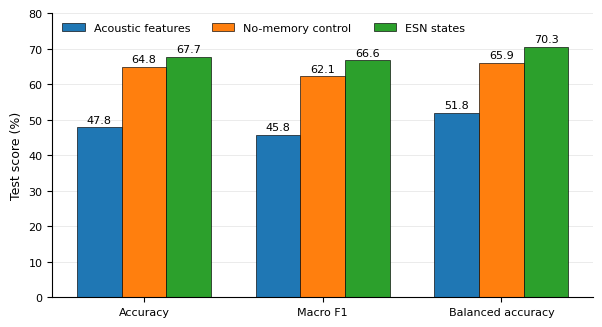

In [4]:
rq1_rows = [
    {
        "Representation": "Acoustic features",
        "Accuracy": results["rq1"]["acoustic_ridge"]["test"]["acc"] * 100,
        "Macro F1": results["rq1"]["acoustic_ridge"]["test"]["macro_f1"] * 100,
        "Balanced accuracy": (
            results["rq1"]["acoustic_ridge"]["test"]["balanced_acc"] * 100
        ),
    },
    {
        "Representation": "No-memory control",
        "Accuracy": no_memory_results["test"]["acc"] * 100,
        "Macro F1": no_memory_results["test"]["macro_f1"] * 100,
        "Balanced accuracy": (
            no_memory_results["test"]["balanced_acc"] * 100
        ),
    },
    {
        "Representation": "ESN states",
        "Accuracy": results["rq1"]["esn_state_ridge"]["test"]["acc"] * 100,
        "Macro F1": results["rq1"]["esn_state_ridge"]["test"]["macro_f1"] * 100,
        "Balanced accuracy": (
            results["rq1"]["esn_state_ridge"]["test"]["balanced_acc"] * 100
        ),
    },
]

rq1_df = pd.DataFrame(rq1_rows).set_index("Representation")

metrics = list(rq1_df.columns)
x = np.arange(len(metrics))
width = 0.25

fig = plt.figure(figsize=(FIGURE_WIDTH, 3.35))
ax = fig.add_subplot(111)

tab10_colours = plt.get_cmap("tab10").colors
series = [
    ("Acoustic features", -width, tab10_colours[0]),
    ("No-memory control", 0.0, tab10_colours[1]),
    ("ESN states", width, tab10_colours[2]),
]
bar_groups = []
for label, offset, colour in series:
    bar_groups.append(
        ax.bar(
            x + offset,
            rq1_df.loc[label, metrics],
            width,
            label=label,
            color=colour,
            edgecolor="black",
            linewidth=0.45,
        )
    )

for bars in bar_groups:
    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.8,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.set_ylabel("Test score (%)")
ax.set_xticks(x, metrics)
ax.set_ylim(0, 80)
ax.legend(frameon=False, ncol=3, loc="upper left")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linewidth=0.5, alpha=0.35)

fig.tight_layout()
save_figure(fig, "Figure_4_1_RQ1_Ridge_Performance")
plt.show()


## Figure 4.2 - RQ1 confusion matrices

Recreates the row-normalised RQ1 confusion matrices in Results Section 4.2.

Saved: Figure_4_2_RQ1_Confusion_Matrices.png
Saved: Figure_4_2_RQ1_Confusion_Matrices.svg


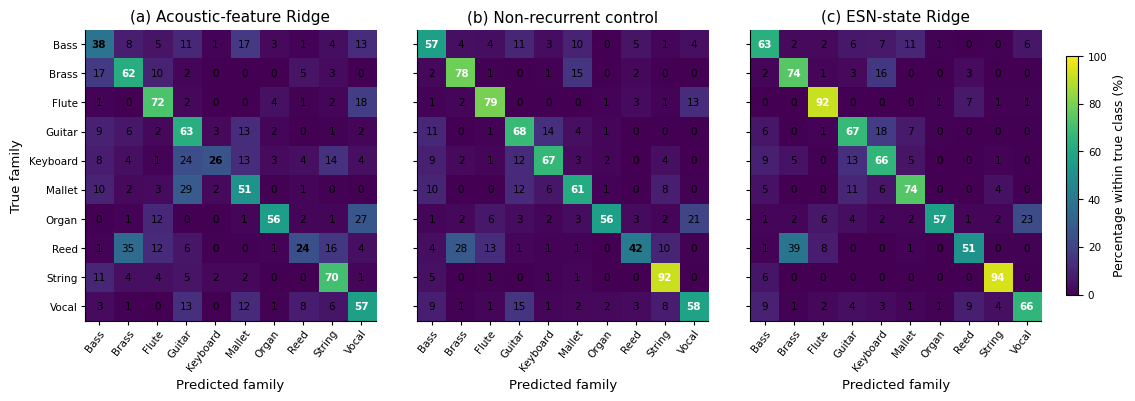

In [5]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(11.2, 3.9),
    sharey=True,
    constrained_layout=True,
)

image = draw_confusion_matrix(
    axes[0],
    y_true,
    y_pred_acoustic,
    CLASS_NAMES,
    "(a) Acoustic-feature Ridge",
    show_y_labels=True,
)

draw_confusion_matrix(
    axes[1],
    y_true,
    y_pred_no_memory,
    CLASS_NAMES,
    "(b) Non-recurrent control",
    show_y_labels=False,
)

draw_confusion_matrix(
    axes[2],
    y_true,
    y_pred_esn,
    CLASS_NAMES,
    "(c) ESN-state Ridge",
    show_y_labels=False,
)

colour_bar = fig.colorbar(
    image,
    ax=axes,
    orientation="vertical",
    fraction=0.035,
    pad=0.025,
    shrink=0.82,
)
colour_bar.set_label(
    "Percentage within true class (%)",
    fontsize=9,
)
colour_bar.ax.tick_params(labelsize=7.5)

save_figure(fig, "Figure_4_2_RQ1_Confusion_Matrices")
plt.show()


## Figure 4.3 - RQ2 five-seed macro F1

Recreates the five-seed RQ2 comparison in Results Section 4.3.

Saved: Figure_4_3_RQ2_Five_Seed_Macro_F1.png
Saved: Figure_4_3_RQ2_Five_Seed_Macro_F1.svg


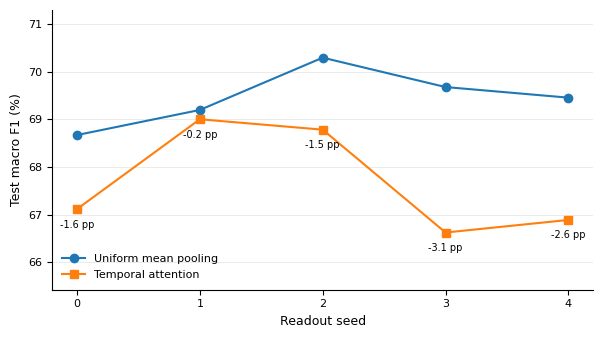

In [6]:
seed_runs = pd.DataFrame(
    results["rq2"]["seed_robustness"]["runs"]
).sort_values("seed")

seeds = seed_runs["seed"].to_numpy()
mean_f1 = seed_runs["mean_macro_f1"].to_numpy() * 100
attention_f1 = seed_runs["attention_macro_f1"].to_numpy() * 100

fig = plt.figure(figsize=(FIGURE_WIDTH, 3.45))
ax = fig.add_subplot(111)

ax.plot(
    seeds,
    mean_f1,
    marker="o",
    linewidth=1.5,
    label="Uniform mean pooling",
)

ax.plot(
    seeds,
    attention_f1,
    marker="s",
    linewidth=1.5,
    label="Temporal attention",
)

for seed, mean_value, attention_value in zip(
    seeds,
    mean_f1,
    attention_f1,
):
    ax.annotate(
        f"{attention_value - mean_value:+.1f} pp",
        (seed, min(mean_value, attention_value) - 0.22),
        ha="center",
        va="top",
        fontsize=7,
    )

ax.set_xlabel("Readout seed")
ax.set_ylabel("Test macro F1 (%)")
ax.set_xticks(seeds)
ax.set_ylim(
    min(mean_f1.min(), attention_f1.min()) - 1.2,
    max(mean_f1.max(), attention_f1.max()) + 1.0,
)
ax.legend(frameon=False, loc="lower left")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linewidth=0.5, alpha=0.35)

fig.tight_layout()
save_figure(fig, "Figure_4_3_RQ2_Five_Seed_Macro_F1")
plt.show()


## Figure 4.4 - RQ2 confusion matrices

Recreates the seed-zero neural confusion matrices in Results Section 4.3.

Saved: Figure_4_4_RQ2_Checkpoint_Confusion_Matrices.png
Saved: Figure_4_4_RQ2_Checkpoint_Confusion_Matrices.svg


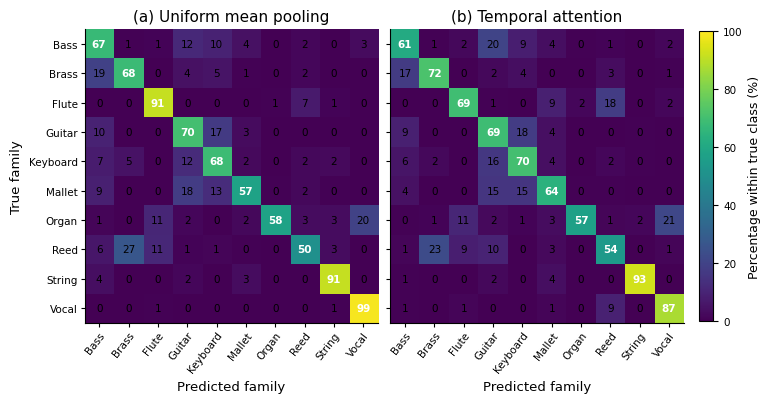

In [7]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(7.6, 4.05),
    sharey=True,
    constrained_layout=True,
)

image = draw_confusion_matrix(
    axes[0],
    y_true,
    y_pred_mean,
    CLASS_NAMES,
    "(a) Uniform mean pooling",
    show_y_labels=True,
)

draw_confusion_matrix(
    axes[1],
    y_true,
    y_pred_attention,
    CLASS_NAMES,
    "(b) Temporal attention",
    show_y_labels=False,
)

colour_bar = fig.colorbar(
    image,
    ax=axes,
    orientation="vertical",
    fraction=0.035,
    pad=0.025,
    shrink=0.82,
)
colour_bar.set_label(
    "Percentage within true class (%)",
    fontsize=9,
)
colour_bar.ax.tick_params(labelsize=7.5)

save_figure(fig, "Figure_4_4_RQ2_Checkpoint_Confusion_Matrices")
plt.show()


## Figure 4.5 - RQ3 attention profile

Recreates the class-balanced five-seed attention profile in Results Section 4.4.

Saved: Figure_4_5_RQ3_Attention_Profile_Five_Seeds.png
Saved: Figure_4_5_RQ3_Attention_Profile_Five_Seeds.svg


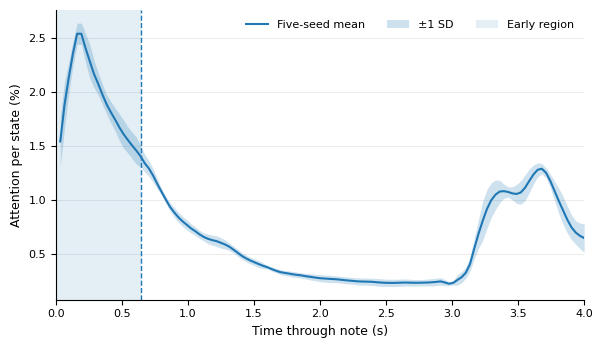

In [8]:
attention_robustness = results["rq3"]["attention_seed_robustness"]

profile_mean = np.asarray(
    attention_robustness["profile_mean"],
    dtype=float,
)
profile_std = np.asarray(
    attention_robustness["profile_std"],
    dtype=float,
)

sample_rate = results["config"]["feature_cfg"]["sr"]
hop_length = results["config"]["feature_cfg"]["hop_length"]
attack_seconds = results["config"]["attack_seconds"]

time_seconds = (
    (np.arange(len(profile_mean)) + 1)
    * hop_length
    / sample_rate
)

mean_percent = profile_mean * 100
std_percent = profile_std * 100

fig = plt.figure(figsize=(FIGURE_WIDTH, 3.55))
ax = fig.add_subplot(111)

line, = ax.plot(
    time_seconds,
    mean_percent,
    linewidth=1.5,
    label="Five-seed mean",
)

ax.fill_between(
    time_seconds,
    np.maximum(mean_percent - std_percent, 0),
    mean_percent + std_percent,
    alpha=0.22,
    color=line.get_color(),
    linewidth=0,
    label="±1 SD",
)

ax.axvspan(
    0,
    attack_seconds,
    alpha=0.12,
    label="Early region",
)
ax.axvline(
    attack_seconds,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel("Time through note (s)")
ax.set_ylabel("Attention per state (%)")
ax.set_xlim(0, time_seconds[-1])
ax.legend(frameon=False, ncol=3, loc="upper right")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linewidth=0.5, alpha=0.35)

fig.tight_layout()
save_figure(fig, "Figure_4_5_RQ3_Attention_Profile_Five_Seeds")
plt.show()


## Figure 4.6 - Attention by instrument family

Recreates the family-specific temporal profiles used in Results Section 4.4.

Saved: Figure_4_6_RQ3_Attention_Profiles_By_Family.png
Saved: Figure_4_6_RQ3_Attention_Profiles_By_Family.svg


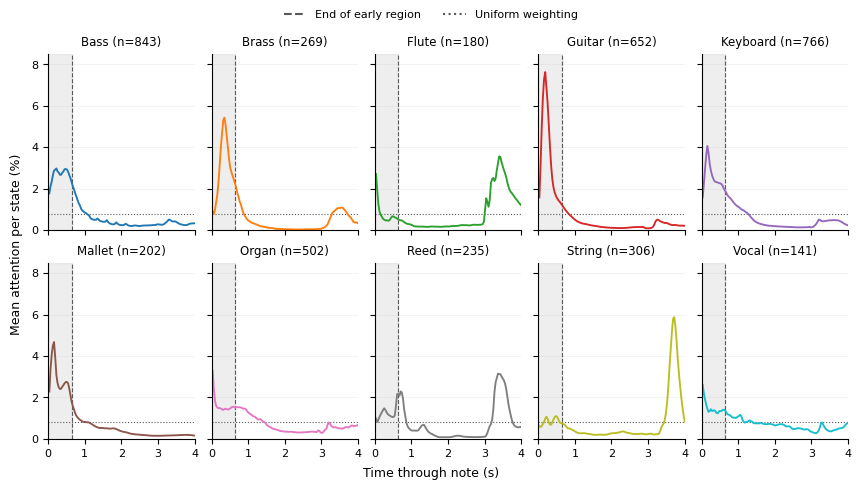

In [9]:
family_counts = {
    int(row["class_id"]): int(row["n_test"])
    for row in results["rq3"]["class_attention_summary"]
}
uniform_attention_percent = 100.0 / family_attention_profiles.shape[1]
family_ymax = np.ceil(family_attention_profiles.max() * 100.0) + 0.5
family_colours = plt.get_cmap("tab10").colors

fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(8.5, 4.8),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for class_id, (ax, class_name, profile, colour) in enumerate(zip(
    axes.flat,
    CLASS_NAMES,
    family_attention_profiles,
    family_colours,
)):
    ax.axvspan(0, attack_seconds, color="0.75", alpha=0.25)
    ax.axvline(attack_seconds, color="0.35", linestyle="--", linewidth=0.8)
    ax.axhline(
        uniform_attention_percent,
        color="0.35",
        linestyle=":",
        linewidth=0.8,
    )
    ax.plot(time_seconds, profile * 100.0, color=colour, linewidth=1.35)
    ax.set_title(f"{class_name} (n={family_counts[class_id]})", fontsize=8.5)
    ax.set_xlim(0, time_seconds[-1])
    ax.set_ylim(0, family_ymax)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linewidth=0.4, alpha=0.25)

fig.supxlabel("Time through note (s)", fontsize=9)
fig.supylabel("Mean attention per state (%)", fontsize=9)
fig.legend(
    handles=[
        plt.Line2D([], [], color="0.35", linestyle="--", label="End of early region"),
        plt.Line2D([], [], color="0.35", linestyle=":", label="Uniform weighting"),
    ],
    frameon=False,
    ncol=2,
    loc="outside upper center",
)

save_figure(fig, "Figure_4_6_RQ3_Attention_Profiles_By_Family")
plt.show()


## Figure 4.7 - Early-region enrichment by family

Recreates the family-level early-attention enrichment comparison in Results Section 4.4.

Saved: Figure_4_7_RQ3_Family_Early_Enrichment.png
Saved: Figure_4_7_RQ3_Family_Early_Enrichment.svg


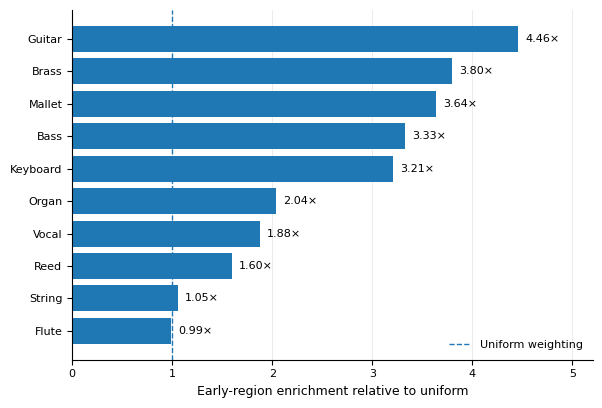

In [10]:
family_df = pd.DataFrame(
    results["rq3"]["class_attention_summary"]
).sort_values(
    "early_enrichment",
    ascending=True,
)

fig = plt.figure(figsize=(FIGURE_WIDTH, 4.15))
ax = fig.add_subplot(111)

bars = ax.barh(
    family_df["family"].str.capitalize(),
    family_df["early_enrichment"],
)

for bar, value in zip(
    bars,
    family_df["early_enrichment"],
):
    ax.text(
        value + 0.07,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}×",
        va="center",
        ha="left",
        fontsize=8,
    )

ax.axvline(
    1.0,
    linestyle="--",
    linewidth=1,
    label="Uniform weighting",
)

ax.set_xlabel("Early-region enrichment relative to uniform")
ax.set_xlim(
    0,
    family_df["early_enrichment"].max() + 0.75,
)
ax.legend(frameon=False, loc="lower right")
ax.set_axisbelow(True)
ax.xaxis.grid(True, linewidth=0.5, alpha=0.35)

fig.tight_layout()
save_figure(fig, "Figure_4_7_RQ3_Family_Early_Enrichment")
plt.show()


## Figure 4.8 - Readout-side masking

Recreates the readout-side masking result in Results Section 4.4.

Saved: Figure_4_8_Readout_Side_Masking.png
Saved: Figure_4_8_Readout_Side_Masking.svg


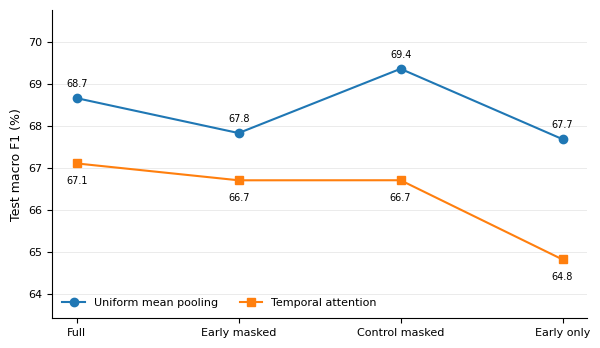

In [11]:
readout_df = ablation_frame("readout_ablation")
x = np.arange(len(readout_df.index))

fig = plt.figure(figsize=(FIGURE_WIDTH, 3.55))
ax = fig.add_subplot(111)

ax.plot(
    x,
    readout_df["Uniform mean pooling"],
    marker="o",
    linewidth=1.5,
    label="Uniform mean pooling",
)

ax.plot(
    x,
    readout_df["Temporal attention"],
    marker="s",
    linewidth=1.5,
    label="Temporal attention",
)

for model in readout_df.columns:
    for xpos, value in zip(x, readout_df[model]):
        offset = 0.22 if model == "Uniform mean pooling" else -0.30

        ax.text(
            xpos,
            value + offset,
            f"{value:.1f}",
            ha="center",
            va="bottom" if offset > 0 else "top",
            fontsize=7,
        )

ax.set_ylabel("Test macro F1 (%)")
ax.set_xticks(x, readout_df.index)
ax.set_ylim(
    readout_df.to_numpy().min() - 1.4,
    readout_df.to_numpy().max() + 1.4,
)
ax.legend(frameon=False, ncol=2, loc="lower left")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linewidth=0.5, alpha=0.35)

fig.tight_layout()
save_figure(fig, "Figure_4_8_Readout_Side_Masking")
plt.show()


## Figure 4.9 - Input-side masking

Recreates the input-side masking result in Results Section 4.4.

Saved: Figure_4_9_Input_Side_Masking.png
Saved: Figure_4_9_Input_Side_Masking.svg


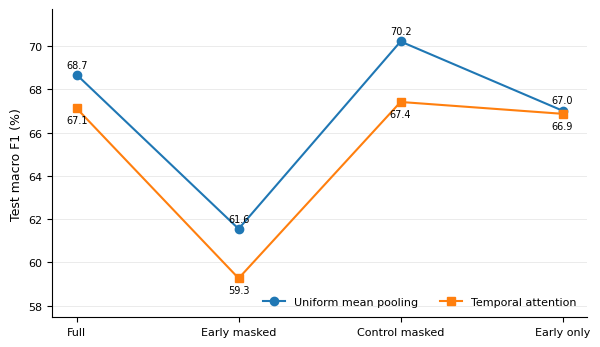

In [12]:
input_df = ablation_frame("input_ablation")
x = np.arange(len(input_df.index))

fig = plt.figure(figsize=(FIGURE_WIDTH, 3.55))
ax = fig.add_subplot(111)

ax.plot(
    x,
    input_df["Uniform mean pooling"],
    marker="o",
    linewidth=1.5,
    label="Uniform mean pooling",
)

ax.plot(
    x,
    input_df["Temporal attention"],
    marker="s",
    linewidth=1.5,
    label="Temporal attention",
)

for model in input_df.columns:
    for xpos, value in zip(x, input_df[model]):
        offset = 0.24 if model == "Uniform mean pooling" else -0.32

        ax.text(
            xpos,
            value + offset,
            f"{value:.1f}",
            ha="center",
            va="bottom" if offset > 0 else "top",
            fontsize=7,
        )

ax.set_ylabel("Test macro F1 (%)")
ax.set_xticks(x, input_df.index)
ax.set_ylim(
    input_df.to_numpy().min() - 1.8,
    input_df.to_numpy().max() + 1.5,
)
ax.legend(frameon=False, ncol=2, loc="lower right")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linewidth=0.5, alpha=0.35)

fig.tight_layout()
save_figure(fig, "Figure_4_9_Input_Side_Masking")
plt.show()


# Log-mel examples

Reads the definitive feature cache to reproduce the acoustic-input examples used with Methodology Section 3.1.2.

In [13]:
feature_cfg = results["config"]["feature_cfg"]
N_MELS = int(feature_cfg["n_mels"])
MAX_T = int(feature_cfg["max_t"])
SR = int(feature_cfg["sr"])
HOP_LENGTH = int(feature_cfg["hop_length"])
ATTACK_FRAMES = int(results["config"]["attack_frames"])
SPECTROGRAM_SAMPLE_SEED = int(results["config"]["seed"])

MEL_CACHE_DIR = (
    PROJECT_DIR
    / "cache_final"
    / f"mel_{results['config']['feature_tag']}"
)
TRAIN_MEL_PATH = MEL_CACHE_DIR / "X_train.npy"
TRAIN_LABEL_PATH = MEL_CACHE_DIR / "y_train.npy"
TRAIN_KEYS_PATH = MEL_CACHE_DIR / "keys_train.json"

missing_mel_files = [
    path
    for path in (TRAIN_MEL_PATH, TRAIN_LABEL_PATH, TRAIN_KEYS_PATH)
    if not path.exists()
]
if missing_mel_files:
    raise FileNotFoundError(
        "Required definitive mel-cache files are missing:\n"
        + "\n".join(f"  - {path}" for path in missing_mel_files)
    )

train_labels = np.load(
    TRAIN_LABEL_PATH, mmap_mode="r", allow_pickle=False
)
with TRAIN_KEYS_PATH.open("r", encoding="utf-8") as f:
    train_keys = json.load(f)

if len(train_labels) != len(train_keys):
    raise ValueError("Cached training labels and keys have different lengths.")

rng = np.random.default_rng(SPECTROGRAM_SAMPLE_SEED)
sampled_example_index = int(rng.integers(0, len(train_labels)))
family_example_indices = {}
for class_id, family in enumerate(CLASS_NAMES):
    candidates = np.flatnonzero(train_labels == class_id)
    if candidates.size == 0:
        raise RuntimeError(f"No cached training examples found for {family}.")
    family_example_indices[family] = int(rng.choice(candidates))

FRAME_SECONDS = HOP_LENGTH / SR
EARLY_SECONDS = ATTACK_FRAMES * FRAME_SECONDS
# NSynth notes are held for three seconds before release (Engel et al., 2017).
NOTE_OFF_SECONDS = 3.0
TIME_EXTENT = (
    -0.5 * FRAME_SECONDS,
    (MAX_T - 0.5) * FRAME_SECONDS,
)
DB_FLOOR, DB_CEIL = -80.0, 0.0


def load_static_mel(index):
    mel_cache = np.load(
        TRAIN_MEL_PATH, mmap_mode="r", allow_pickle=False
    )
    panel = np.asarray(
        mel_cache[index, :, :N_MELS], dtype=np.float32
    ).copy()
    del mel_cache
    if panel.shape != (MAX_T, N_MELS):
        raise ValueError(f"Unexpected cached mel-panel shape: {panel.shape}.")
    if not np.isfinite(panel).all():
        raise ValueError("Cached mel panel contains NaN or infinite values.")
    return panel


def draw_mel_panel(ax, panel, show_legend=False, marker_lw=1.2):
    image = ax.imshow(
        panel.T,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap="viridis",
        vmin=DB_FLOOR,
        vmax=DB_CEIL,
        extent=(TIME_EXTENT[0], TIME_EXTENT[1], 0.5, N_MELS + 0.5),
    )
    ax.axvspan(
        TIME_EXTENT[0], EARLY_SECONDS, color="white", alpha=0.12, lw=0
    )
    ax.axvline(
        EARLY_SECONDS,
        color="white",
        linestyle="--",
        linewidth=marker_lw,
        label=f"end of early region ({EARLY_SECONDS:.2f} s)",
    )
    ax.axvline(
        NOTE_OFF_SECONDS,
        color="white",
        linestyle=":",
        linewidth=marker_lw,
        label=f"note-off ({NOTE_OFF_SECONDS:.1f} s)",
    )
    ax.set_xlim(*TIME_EXTENT)
    if show_legend:
        ax.legend(loc="upper right", fontsize=7.5, framealpha=0.75)
    return image


sampled_panel = load_static_mel(sampled_example_index)
sampled_family = CLASS_NAMES[int(train_labels[sampled_example_index])]
sampled_key = train_keys[sampled_example_index]

print(f"Sampling seed: {SPECTROGRAM_SAMPLE_SEED}")
print(f"Sampled example: {sampled_key} ({sampled_family})")
print(f"Static log-mel range: {sampled_panel.min():.2f} to {sampled_panel.max():.2f} dB")


Sampling seed: 42
Sampled example: bass_synthetic_043-050-100 (Bass)
Static log-mel range: -80.00 to 0.00 dB


## Log-mel input representation

Shows the 64 Mel bands, early region and nominal note-off used to explain the model input.

Saved: Figure_3_1_LogMel_Input_Representation.png
Saved: Figure_3_1_LogMel_Input_Representation.svg


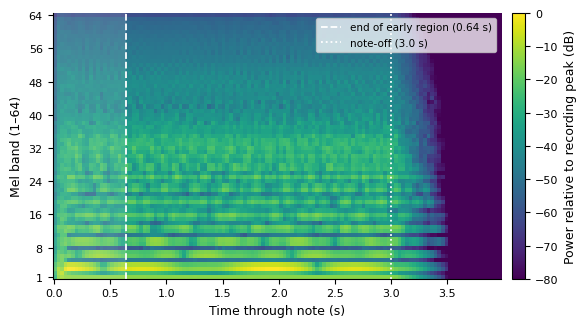

Displayed static feature channels: 64 Mel bands
Sampled recording: bass_synthetic_043-050-100 (Bass)
Delta and delta-delta channels are intentionally excluded from this figure.


In [14]:
fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, 3.35))
image = draw_mel_panel(
    ax, sampled_panel, show_legend=True, marker_lw=1.3
)
ax.set_ylim(0.5, N_MELS + 0.5)
ax.set_yticks([1, 8, 16, 24, 32, 40, 48, 56, 64])
ax.set_xlabel("Time through note (s)")
ax.set_ylabel("Mel band (1–64)")
colourbar = fig.colorbar(image, ax=ax, pad=0.02)
colourbar.set_label("Power relative to recording peak (dB)")
fig.tight_layout()
save_figure(fig, "Figure_3_1_LogMel_Input_Representation")
plt.show()

print(f"Displayed static feature channels: {sampled_panel.shape[1]} Mel bands")
print(f"Sampled recording: {sampled_key} ({sampled_family})")
print("Delta and delta-delta channels are intentionally excluded from this figure.")


## Examples by instrument family

Shows one cached training example from each of the ten retained NSynth families.

Saved: Supplementary_LogMel_Examples_By_Family.png
Saved: Supplementary_LogMel_Examples_By_Family.svg


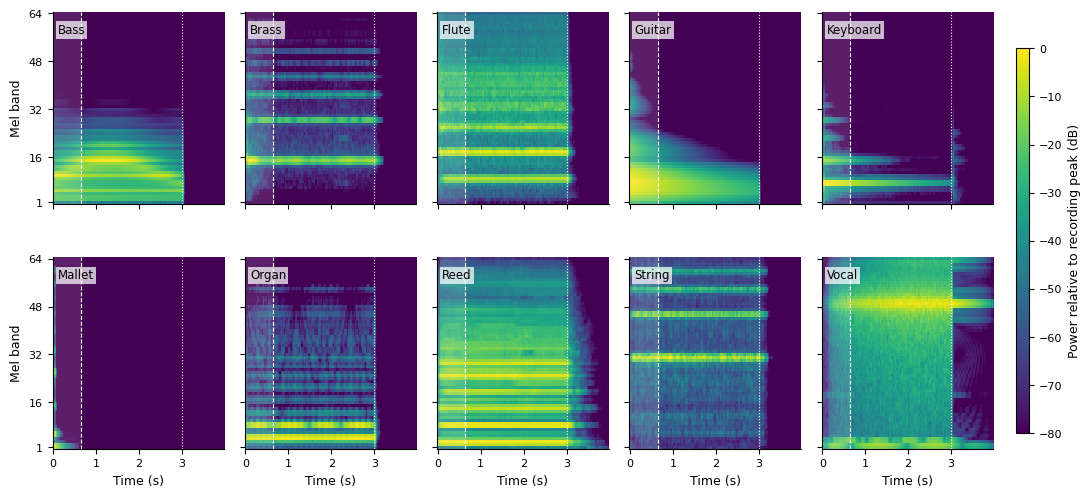

Saved: spectrogram_example_manifest.json


,Family,Index,NSynth key
0,Bass,50673,bass_synthetic_106-046-127
1,Brass,73770,brass_acoustic_042-077-050
2,Flute,81999,flute_acoustic_020-056-127
3,Guitar,101077,guitar_electronic_007-035-025
4,Keyboard,164105,keyboard_electronic_097-065-050
5,Mallet,174372,mallet_acoustic_007-036-127
6,Organ,229677,organ_electronic_078-055-100
7,Reed,242913,reed_acoustic_013-048-075
8,String,255856,string_acoustic_006-091-127
9,Vocal,278870,vocal_synthetic_004-039-127


In [15]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(11.2, 5.2),
    sharex=True,
    sharey=True,
)

image = None
family_examples = {}
for class_id, (ax, family) in enumerate(zip(axes.ravel(), CLASS_NAMES)):
    index = family_example_indices[family]
    key = train_keys[index]
    panel = load_static_mel(index)
    image = draw_mel_panel(ax, panel, show_legend=False, marker_lw=0.8)
    ax.text(
        0.03,
        0.94,
        family,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.5,
        bbox={"facecolor": "white", "alpha": 0.72, "edgecolor": "none", "pad": 1.5},
    )
    family_examples[family] = {"index": index, "key": key}
    del panel

band_ticks = [1, 16, 32, 48, 64]
for ax in axes[:, 0]:
    ax.set_yticks(band_ticks)
    ax.set_ylabel("Mel band", fontsize=9)
for ax in axes[-1, :]:
    ax.set_xlabel("Time (s)", fontsize=9)

fig.subplots_adjust(left=0.07, right=0.91, bottom=0.10, top=0.94, wspace=0.12, hspace=0.28)
colourbar_axis = fig.add_axes([0.93, 0.13, 0.012, 0.74])
colourbar = fig.colorbar(image, cax=colourbar_axis)
colourbar.set_label("Power relative to recording peak (dB)", fontsize=9)
save_figure(fig, "Supplementary_LogMel_Examples_By_Family")
plt.show()

spectrogram_manifest = {
    "sampling_seed": SPECTROGRAM_SAMPLE_SEED,
    "sampling_population": "definitive cached NSynth training split",
    "sampled_example": {
        "index": sampled_example_index,
        "key": sampled_key,
        "family": sampled_family,
    },
    "family_examples": family_examples,
    "early_region_seconds": EARLY_SECONDS,
    "note_off_seconds": NOTE_OFF_SECONDS,
}
manifest_path = FIG_DIR / "spectrogram_example_manifest.json"
with manifest_path.open("w", encoding="utf-8") as f:
    json.dump(spectrogram_manifest, f, indent=2)
print(f"Saved: {manifest_path.name}")

display(pd.DataFrame([
    {"Family": family, "Index": record["index"], "NSynth key": record["key"]}
    for family, record in family_examples.items()
]))

del train_labels, train_keys, sampled_panel


# Export summary

Lists the generated dissertation figure files.

In [16]:
generated_files = sorted(GENERATED_FILES)

summary = pd.DataFrame({
    "File": [path.name for path in generated_files],
    "Size (KB)": [
        round(path.stat().st_size / 1024, 1)
        for path in generated_files
    ],
})

print(f"Generated {len(generated_files)} files in:")
print(FIG_DIR.resolve())

summary


Generated 22 files in:
/home/olliechandler/ESN-NSYNTH/results_final/run_35d8eed08b/figures_dissertation


,File,Size (KB)
0,Figure_3_1_LogMel_Input_Representation.png,123.9
1,Figure_3_1_LogMel_Input_Representation.svg,70.2
2,Figure_4_1_RQ1_Ridge_Performance.png,73.6
3,Figure_4_1_RQ1_Ridge_Performance.svg,37.9
4,Figure_4_2_RQ1_Confusion_Matrices.png,270.9
5,Figure_4_2_RQ1_Confusion_Matrices.svg,138.6
6,Figure_4_3_RQ2_Five_Seed_Macro_F1.png,94.1
7,Figure_4_3_RQ2_Five_Seed_Macro_F1.svg,34.2
8,Figure_4_4_RQ2_Checkpoint_Confusion_Matrices.png,210.4
9,Figure_4_4_RQ2_Checkpoint_Confusion_Matrices.svg,104.8


# Consolidated results tables

Collects the RQ1 to RQ3 results used in Chapter 4 and Appendix E.

In [17]:
def show_results_table(title, frame):
    print(f"\n{title}")
    display(Markdown(f"### {title}"))
    display(frame)


def percent(value):
    return float(value) * 100.0


def per_family_metrics(prediction_map):
    table = pd.DataFrame({"Family": CLASS_NAMES})
    support_reference = None

    for model_name, predictions in prediction_map.items():
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true,
            predictions,
            labels=np.arange(len(CLASS_NAMES)),
            zero_division=0,
        )
        if support_reference is None:
            support_reference = support
        elif not np.array_equal(support_reference, support):
            raise ValueError("Per-family supports differ across cached predictions.")

        table[f"{model_name} precision (%)"] = np.round(precision * 100, 2)
        table[f"{model_name} recall (%)"] = np.round(recall * 100, 2)
        table[f"{model_name} F1 (%)"] = np.round(f1 * 100, 2)

    table.insert(1, "Support", support_reference.astype(int))
    return table


def ablation_results_table(section_name):
    condition_labels = {
        "full": "Full",
        "mask_early": "Early masked",
        "mask_control": "Control masked",
        "keep_early_only": "Early only",
    }
    readout_labels = {
        "mean": "Uniform mean pooling",
        "attention": "Temporal attention",
    }
    rows = []
    for condition_key, condition_label in condition_labels.items():
        for readout_key, readout_label in readout_labels.items():
            entry = results["rq3"][section_name][condition_key][readout_key]
            rows.append({
                "Condition": condition_label,
                "Readout": readout_label,
                "Best validation macro F1 (%)": round(percent(entry["best_validation_score"]), 2),
                "Best epoch": int(entry["best_epoch"]),
                "Test accuracy (%)": round(percent(entry["test"]["acc"]), 2),
                "Test macro F1 (%)": round(percent(entry["test"]["macro_f1"]), 2),
                "Test balanced accuracy (%)": round(percent(entry["test"]["balanced_acc"]), 2),
            })
    return pd.DataFrame(rows)


rq1_sources = [
    ("Acoustic-feature Ridge", results["rq1"]["acoustic_ridge"]),
    ("Non-recurrent control", no_memory_results),
    ("ESN-state Ridge", results["rq1"]["esn_state_ridge"]),
]

rq1_performance_rows = []
for model_name, source in rq1_sources:
    rq1_performance_rows.append({
        "Model": model_name,
        "Selected alpha": source["alpha"],
        "Validation accuracy (%)": round(percent(source["validation"]["acc"]), 2),
        "Validation macro F1 (%)": round(percent(source["validation"]["macro_f1"]), 2),
        "Validation balanced accuracy (%)": round(percent(source["validation"]["balanced_acc"]), 2),
        "Test accuracy (%)": round(percent(source["test"]["acc"]), 2),
        "Test macro F1 (%)": round(percent(source["test"]["macro_f1"]), 2),
        "Test balanced accuracy (%)": round(percent(source["test"]["balanced_acc"]), 2),
    })
rq1_performance_table = pd.DataFrame(rq1_performance_rows)

rq1_tuning_rows = []
for model_name, source in rq1_sources:
    for point in source["tuning_curve"]:
        rq1_tuning_rows.append({
            "Model": model_name,
            "Alpha": point["alpha"],
            "Validation accuracy (%)": round(percent(point["acc"]), 3),
            "Validation macro F1 (%)": round(percent(point["macro_f1"]), 3),
            "Validation balanced accuracy (%)": round(percent(point["balanced_acc"]), 3),
        })
rq1_tuning_table = pd.DataFrame(rq1_tuning_rows)

rq1_mcnemar_sources = [
    ("ESN-state Ridge vs acoustic-feature Ridge", results["rq1"]["mcnemar"]),
    ("No-memory control vs acoustic-feature Ridge", no_memory_mcnemar["vs_acoustic_ridge"]),
    ("No-memory control vs ESN-state Ridge", no_memory_mcnemar["vs_esn_state_ridge"]),
]
rq1_mcnemar_table = pd.DataFrame([
    {
        "Comparison": comparison,
        "b": test["b"],
        "c": test["c"],
        "Discordant": test["discordant"],
        "Corrected chi-square": test["chi_square_corrected"],
        "Corrected p": test["p_corrected"],
        "Exact p": test["p_exact"],
    }
    for comparison, test in rq1_mcnemar_sources
])
rq1_family_table = per_family_metrics({
    "Acoustic": y_pred_acoustic,
    "No memory": y_pred_no_memory,
    "ESN": y_pred_esn,
})

rq2_checkpoint_rows = []
for label, key in [("Uniform mean pooling", "uniform_mean"), ("Temporal attention", "attention")]:
    entry = results["rq2"][key]
    rq2_checkpoint_rows.append({
        "Readout": label,
        "Best epoch": int(entry["history"]["best_epoch"]),
        "Best validation macro F1 (%)": round(percent(entry["history"]["best_score"]), 2),
        "Test accuracy (%)": round(percent(entry["test"]["acc"]), 2),
        "Test macro F1 (%)": round(percent(entry["test"]["macro_f1"]), 2),
        "Test balanced accuracy (%)": round(percent(entry["test"]["balanced_acc"]), 2),
        "Checkpoint": Path(entry["history"]["checkpoint"]).name,
    })
rq2_checkpoint_table = pd.DataFrame(rq2_checkpoint_rows)

rq2_seed_table = pd.DataFrame(results["rq2"]["seed_robustness"]["runs"])[[
    "seed", "mean_acc", "mean_macro_f1", "mean_balanced_acc",
    "attention_acc", "attention_macro_f1", "attention_balanced_acc",
    "accuracy_difference", "macro_f1_difference",
    "balanced_accuracy_difference", "mean_best_epoch", "attention_best_epoch",
]].copy()
rq2_seed_percent_columns = [column for column in rq2_seed_table.columns if column not in {"seed", "mean_best_epoch", "attention_best_epoch"}]
rq2_seed_table[rq2_seed_percent_columns] = (rq2_seed_table[rq2_seed_percent_columns] * 100).round(3)
rq2_seed_table = rq2_seed_table.rename(columns={
    "seed": "Seed",
    "mean_acc": "Mean accuracy (%)",
    "mean_macro_f1": "Mean macro F1 (%)",
    "mean_balanced_acc": "Mean balanced accuracy (%)",
    "attention_acc": "Attention accuracy (%)",
    "attention_macro_f1": "Attention macro F1 (%)",
    "attention_balanced_acc": "Attention balanced accuracy (%)",
    "accuracy_difference": "Attention − mean accuracy (pp)",
    "macro_f1_difference": "Attention − mean macro F1 (pp)",
    "balanced_accuracy_difference": "Attention − mean balanced accuracy (pp)",
    "mean_best_epoch": "Mean best epoch",
    "attention_best_epoch": "Attention best epoch",
})

robustness = results["rq2"]["seed_robustness"]
rq2_aggregate_table = pd.DataFrame([
    {
        "Metric": label,
        "Mean pooling: mean (%)": round(percent(robustness[f"mean_pooling_{key}_mean"]), 3),
        "Mean pooling: SD (pp)": round(percent(robustness[f"mean_pooling_{key}_std"]), 3),
        "Attention: mean (%)": round(percent(robustness[f"attention_{key}_mean"]), 3),
        "Attention: SD (pp)": round(percent(robustness[f"attention_{key}_std"]), 3),
        "Attention − mean: mean (pp)": round(percent(robustness[f"{difference_key}_difference_mean"]), 3),
        "Difference SD (pp)": round(percent(robustness[f"{difference_key}_difference_std"]), 3),
        "Attention wins": int(robustness[f"{difference_key}_attention_wins"]),
        "Seeds": int(robustness["n_seeds"]),
    }
    for label, key, difference_key in [
        ("Accuracy", "accuracy", "accuracy"),
        ("Macro F1", "macro_f1", "macro_f1"),
        ("Balanced accuracy", "balanced_accuracy", "balanced_accuracy"),
    ]
])

rq2_mcnemar_table = pd.DataFrame([
    {
        "Comparison": label,
        "b": test["b"],
        "c": test["c"],
        "Discordant": test["discordant"],
        "Corrected chi-square": test["chi_square_corrected"],
        "Corrected p": test["p_corrected"],
        "Exact p": test["p_exact"],
    }
    for label, test in [
        ("Attention vs uniform mean pooling", results["rq2"]["mcnemar_vs_uniform"]),
        ("Attention vs ESN-state Ridge", results["rq2"]["mcnemar_vs_ridge"]),
    ]
])
rq2_family_table = per_family_metrics({
    "Uniform mean": y_pred_mean,
    "Attention": y_pred_attention,
})

attention_seed_robustness = results["rq3"]["attention_seed_robustness"]
rq3_attention_summary_table = pd.DataFrame([
    {
        "Profile": "Primary seed: class balanced",
        "Early mass (%)": round(percent(results["rq3"]["class_balanced_early_mass"]), 3),
        "Early enrichment (× uniform)": round(results["rq3"]["class_balanced_early_enrichment"], 3),
        "Across-seed SD": np.nan,
    },
    {
        "Profile": "Primary seed: sample weighted",
        "Early mass (%)": round(percent(results["rq3"]["sample_weighted_early_mass"]), 3),
        "Early enrichment (× uniform)": round(results["rq3"]["sample_weighted_early_enrichment"], 3),
        "Across-seed SD": np.nan,
    },
    {
        "Profile": "Five-seed class-balanced mean",
        "Early mass (%)": round(percent(attention_seed_robustness["early_mass_mean"]), 3),
        "Early enrichment (× uniform)": round(attention_seed_robustness["early_enrichment_mean"], 3),
        "Across-seed SD": round(attention_seed_robustness["early_enrichment_std"], 3),
    },
    {
        "Profile": "Uniform temporal reference",
        "Early mass (%)": round(percent(results["rq3"]["class_balanced_uniform_early_mass"]), 3),
        "Early enrichment (× uniform)": 1.0,
        "Across-seed SD": np.nan,
    },
])

rq3_enrichment_curve_table = pd.concat([
    pd.DataFrame(results["rq3"]["class_balanced_enrichment_curve"]).assign(Weighting="Class balanced"),
    pd.DataFrame(results["rq3"]["sample_weighted_enrichment_curve"]).assign(Weighting="Sample weighted"),
], ignore_index=True)[["Weighting", "K", "seconds", "weight_mass", "enrichment"]]
rq3_enrichment_curve_table["weight_mass"] = (rq3_enrichment_curve_table["weight_mass"] * 100).round(3)
rq3_enrichment_curve_table = rq3_enrichment_curve_table.rename(columns={
    "K": "Early states (K)",
    "seconds": "Time (s)",
    "weight_mass": "Attention mass (%)",
    "enrichment": "Enrichment (× uniform)",
}).round({"Time (s)": 3, "Enrichment (× uniform)": 3})

rq3_family_attention_table = pd.DataFrame(results["rq3"]["class_attention_summary"])[[
    "class_id", "family", "n_test", "early_mass", "early_enrichment"
]].copy()
rq3_family_attention_table["early_mass"] = (rq3_family_attention_table["early_mass"] * 100).round(3)
rq3_family_attention_table["early_enrichment"] = rq3_family_attention_table["early_enrichment"].round(3)
rq3_family_attention_table = rq3_family_attention_table.rename(columns={
    "class_id": "Class ID",
    "family": "Family",
    "n_test": "Test examples",
    "early_mass": "Early attention mass (%)",
    "early_enrichment": "Early enrichment (× uniform)",
})
rq3_family_attention_table["Family"] = rq3_family_attention_table["Family"].str.capitalize()

rq3_attention_seed_table = pd.DataFrame(attention_seed_robustness["runs"]).rename(columns={
    "seed": "Seed",
    "class_balanced_early_mass": "Class-balanced early mass (%)",
    "class_balanced_early_enrichment": "Class-balanced enrichment (× uniform)",
})
rq3_attention_seed_table["Class-balanced early mass (%)"] = (rq3_attention_seed_table["Class-balanced early mass (%)"] * 100).round(3)
rq3_attention_seed_table["Class-balanced enrichment (× uniform)"] = rq3_attention_seed_table["Class-balanced enrichment (× uniform)"].round(3)

rq3_readout_ablation_table = ablation_results_table("readout_ablation")
rq3_input_ablation_table = ablation_results_table("input_ablation")

combined_findings_table = pd.DataFrame([
    {
        "Research question": "RQ1",
        "Comparison": "ESN-state Ridge − acoustic-feature Ridge",
        "Test macro F1 difference (pp)": round(percent(results["rq1"]["esn_state_ridge"]["test"]["macro_f1"] - results["rq1"]["acoustic_ridge"]["test"]["macro_f1"]), 3),
    },
    {
        "Research question": "RQ1",
        "Comparison": "ESN-state Ridge − no-memory control",
        "Test macro F1 difference (pp)": round(percent(results["rq1"]["esn_state_ridge"]["test"]["macro_f1"] - no_memory_results["test"]["macro_f1"]), 3),
    },
    {
        "Research question": "RQ2",
        "Comparison": "Attention − uniform mean, primary checkpoint",
        "Test macro F1 difference (pp)": round(percent(results["rq2"]["attention"]["test"]["macro_f1"] - results["rq2"]["uniform_mean"]["test"]["macro_f1"]), 3),
    },
    {
        "Research question": "RQ2",
        "Comparison": "Attention − uniform mean, five-seed average",
        "Test macro F1 difference (pp)": round(percent(robustness["macro_f1_difference_mean"]), 3),
    },
    {
        "Research question": "RQ3",
        "Comparison": "Mean pooling: input early-masked − full",
        "Test macro F1 difference (pp)": round(percent(results["rq3"]["input_ablation"]["mask_early"]["mean"]["test"]["macro_f1"] - results["rq3"]["input_ablation"]["full"]["mean"]["test"]["macro_f1"]), 3),
    },
    {
        "Research question": "RQ3",
        "Comparison": "Attention: input early-masked − full",
        "Test macro F1 difference (pp)": round(percent(results["rq3"]["input_ablation"]["mask_early"]["attention"]["test"]["macro_f1"] - results["rq3"]["input_ablation"]["full"]["attention"]["test"]["macro_f1"]), 3),
    },
])

all_results_tables = [
    ("RQ1 - Validation and test performance", rq1_performance_table),
    ("RQ1 - Complete Ridge alpha-validation sweep", rq1_tuning_table),
    ("RQ1 - Paired McNemar tests", rq1_mcnemar_table),
    ("RQ1 - Per-family cached test metrics", rq1_family_table),
    ("RQ2 - Primary checkpoint performance", rq2_checkpoint_table),
    ("RQ2 - Five matched readout seeds", rq2_seed_table),
    ("RQ2 - Five-seed aggregate robustness", rq2_aggregate_table),
    ("RQ2 - Paired McNemar tests", rq2_mcnemar_table),
    ("RQ2 - Per-family cached checkpoint metrics", rq2_family_table),
    ("RQ3 - Overall early-attention summaries", rq3_attention_summary_table),
    ("RQ3 - Early-window enrichment curves", rq3_enrichment_curve_table),
    ("RQ3 - Attention by instrument family", rq3_family_attention_table),
    ("RQ3 - Attention-profile robustness across seeds", rq3_attention_seed_table),
    ("RQ3 - Readout-side temporal masking", rq3_readout_ablation_table),
    ("RQ3 - Input-side temporal masking", rq3_input_ablation_table),
    ("Combined cross-RQ headline comparisons", combined_findings_table),
]

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", 180,
):
    for table_title, table in all_results_tables:
        show_results_table(table_title, table)

print(f"\nDisplayed {len(all_results_tables)} combined cache-only results tables.")



RQ1 - Validation and test performance


### RQ1 - Validation and test performance

,Model,Selected alpha,Validation accuracy (%),Validation macro F1 (%),Validation balanced accuracy (%),Test accuracy (%),Test macro F1 (%),Test balanced accuracy (%)
0,Acoustic-feature Ridge,100.0,47.89,45.88,52.94,47.78,45.79,51.84
1,Non-recurrent control,1.0,64.70,62.01,66.14,64.79,62.13,65.86
2,ESN-state Ridge,0.1,66.62,65.43,69.42,67.75,66.65,70.35



RQ1 - Complete Ridge alpha-validation sweep


### RQ1 - Complete Ridge alpha-validation sweep

...

,Condition,Readout,Best validation macro F1 (%),Best epoch,Test accuracy (%),Test macro F1 (%),Test balanced accuracy (%)
0,Full,Uniform mean pooling,68.10,24,69.26,68.67,72.00
1,Full,Temporal attention,66.80,21,67.55,67.12,69.59
2,Early masked,Uniform mean pooling,62.15,42,59.67,61.55,64.95
3,Early masked,Temporal attention,59.58,33,57.91,59.27,60.49
4,Control masked,Uniform mean pooling,69.74,46,70.92,70.21,73.05
5,Control masked,Temporal attention,67.27,34,68.14,67.41,69.63
6,Early only,Uniform mean pooling,67.07,20,67.99,67.01,69.90
7,Early only,Temporal attention,66.08,30,67.55,66.87,68.54



Combined cross-RQ headline comparisons


### Combined cross-RQ headline comparisons

,Research question,Comparison,Test macro F1 difference (pp)
0,RQ1,ESN-state Ridge − acoustic-feature Ridge,20.857
1,RQ1,ESN-state Ridge − no-memory control,4.512
2,RQ2,"Attention − uniform mean, primary checkpoint",-1.554
3,RQ2,"Attention − uniform mean, five-seed average",-1.775
4,RQ3,Mean pooling: input early-masked − full,-7.120
5,RQ3,Attention: input early-masked − full,-7.850



Displayed 16 combined cache-only results tables.


# Reservoir selection and cached-state tables

Collects the locked search results and cache statistics used in Results Section 4.1.1 and Appendix D. Separate state-regime diagnostics are included only if their retained JSON file is present.

In [18]:
selected_cfg = reservoir_selection["reservoir_cfg"]
selected_validation = reservoir_selection["selected_validation"]
search_design = reservoir_selection["search_design"]
ridge_extension = reservoir_selection["ridge_extension"]

selected_reservoir_table = pd.DataFrame([{
    "Selection status": reservoir_selection["selection_status"],
    "Selection metric": reservoir_selection["selection_metric"],
    "Reservoir seed": reservoir_selection["reservoir_seed"],
    "Units": selected_cfg["units"],
    "Spectral radius": selected_cfg["sr"],
    "Leak rate": selected_cfg["lr"],
    "Input scaling": selected_cfg["input_scaling"],
    "Recurrent connectivity": selected_cfg["rc_connectivity"],
    "Pooled components": "mean, max, final state",
    "Pooled dimensions": int(selected_cfg["units"] * 3),
    "Selected Ridge alpha": selected_validation["ridge_alpha"],
    "Validation accuracy (%)": round(percent(selected_validation["acc"]), 3),
    "Validation macro F1 (%)": round(percent(selected_validation["macro_f1"]), 3),
    "Validation balanced accuracy (%)": round(percent(selected_validation["balanced_acc"]), 3),
    "Final selection stage": selected_validation["stage"],
    "Selected alpha is boundary": ridge_extension["selected_alpha_is_boundary"],
}])

search_design_table = pd.DataFrame([
    {"Design item": "Stage 1 reservoir units", "Value": search_design["stage1_units"]},
    {"Design item": "Stage train subset", "Value": search_design["train_subset_n"]},
    {"Design item": "Stage validation subset", "Value": search_design["validation_subset_n"]},
    {"Design item": "Spectral-radius grid", "Value": str(search_design["sr_grid"])},
    {"Design item": "Leak-rate grid", "Value": str(search_design["lr_grid"])},
    {"Design item": "Base input-scaling grid", "Value": str(search_design["base_input_scaling_grid"])},
    {"Design item": "Extended input-scaling grid", "Value": str(search_design["extended_input_scaling_grid"])},
    {"Design item": "Reservoir-size grid", "Value": str(search_design["size_grid"])},
    {"Design item": "Confirmation train examples", "Value": search_design["confirmation_train_n"]},
    {"Design item": "Confirmation validation examples", "Value": search_design["confirmation_valid_n"]},
    {"Design item": "Ridge solver", "Value": search_design["ridge_solver"]},
    {"Design item": "Ridge tolerance", "Value": search_design["ridge_tol"]},
    {"Design item": "Ridge maximum iterations", "Value": search_design["ridge_max_iter"]},
    {"Design item": "Complete Ridge alpha grid", "Value": str(search_design["ridge_alphas"])},
])

stage_frames = {
    stage_name: pd.read_csv(stage_path)
    for stage_name, stage_path in RESERVOIR_STAGE_PATHS.items()
}
stage_sample_sizes = {
    "Stage 1 coarse": (search_design["train_subset_n"], search_design["validation_subset_n"]),
    "Stage 1 boundary": (search_design["train_subset_n"], search_design["validation_subset_n"]),
    "Stage 2 size": (search_design["train_subset_n"], search_design["validation_subset_n"]),
    "Stage 3 confirmation": (search_design["confirmation_train_n"], search_design["confirmation_valid_n"]),
    "Stage 3 Ridge extension": (search_design["confirmation_train_n"], search_design["confirmation_valid_n"]),
}
stage_overview_rows = []
stage_winner_rows = []
for stage_name, frame in stage_frames.items():
    winner = frame.loc[frame["val_macro_f1"].idxmax()]
    train_n, valid_n = stage_sample_sizes[stage_name]
    stage_overview_rows.append({
        "Search stage": stage_name,
        "Candidates": len(frame),
        "Train examples": train_n,
        "Validation examples": valid_n,
        "Best validation macro F1 (%)": round(percent(winner["val_macro_f1"]), 3),
    })
    stage_winner_rows.append({
        "Search stage": stage_name,
        "Units": int(winner["units"]),
        "Spectral radius": winner["sr"],
        "Leak rate": winner["lr"],
        "Input scaling": winner["input_scaling"],
        "Selected alpha": winner["alpha"],
        "Validation accuracy (%)": round(percent(winner["val_acc"]), 3),
        "Validation macro F1 (%)": round(percent(winner["val_macro_f1"]), 3),
        "Validation balanced accuracy (%)": round(percent(winner["val_balanced_acc"]), 3),
    })
stage_overview_table = pd.DataFrame(stage_overview_rows)
stage_winners_table = pd.DataFrame(stage_winner_rows)

confirmation_candidates_table = stage_frames["Stage 3 confirmation"].copy()
confirmation_candidates_table[["val_acc", "val_macro_f1", "val_balanced_acc"]] = (
    confirmation_candidates_table[["val_acc", "val_macro_f1", "val_balanced_acc"]] * 100
).round(3)
confirmation_candidates_table = confirmation_candidates_table.rename(columns={
    "units": "Units", "sr": "Spectral radius", "lr": "Leak rate",
    "input_scaling": "Input scaling", "alpha": "Selected alpha",
    "val_acc": "Validation accuracy (%)",
    "val_macro_f1": "Validation macro F1 (%)",
    "val_balanced_acc": "Validation balanced accuracy (%)",
})[["Units", "Spectral radius", "Leak rate", "Input scaling", "Selected alpha", "Validation accuracy (%)", "Validation macro F1 (%)", "Validation balanced accuracy (%)"]]

ridge_extension_curve_table = pd.read_csv(RIDGE_EXTENSION_CURVE_PATH)
ridge_extension_curve_table[["acc", "macro_f1", "balanced_acc"]] = (
    ridge_extension_curve_table[["acc", "macro_f1", "balanced_acc"]] * 100
).round(3)
ridge_extension_curve_table = ridge_extension_curve_table.rename(columns={
    "units": "Units", "sr": "Spectral radius", "lr": "Leak rate",
    "input_scaling": "Input scaling", "alpha": "Ridge alpha",
    "acc": "Validation accuracy (%)", "macro_f1": "Validation macro F1 (%)",
    "balanced_acc": "Validation balanced accuracy (%)",
})[["Units", "Spectral radius", "Leak rate", "Input scaling", "Ridge alpha", "Validation accuracy (%)", "Validation macro F1 (%)", "Validation balanced accuracy (%)"]]

state_cache_rows = []
state_manifests = {}
for split in ("train", "valid", "test"):
    with STATE_MANIFEST_PATHS[split].open("r", encoding="utf-8") as f:
        manifest = json.load(f)
    state_manifests[split] = manifest
    state_array = np.load(STATE_ARRAY_PATHS[split], mmap_mode="r", allow_pickle=False)
    if state_array.shape[0] != manifest["n_examples"]:
        raise ValueError(f"Cached {split} state shape does not match its manifest.")
    state_cache_rows.append({
        "Split": split.capitalize(),
        "Examples": manifest["n_examples"],
        "Array shape": str(tuple(state_array.shape)),
        "Frames per example": int(state_array.shape[1]),
        "Units per state": int(state_array.shape[2]),
        "Stored dtype": manifest["state_dtype"],
        "File size (GiB)": round(STATE_ARRAY_PATHS[split].stat().st_size / (1024 ** 3), 3),
        "State tag": manifest["state_tag"],
        "Ordered-key SHA-1": manifest["ordered_key_hash"],
    })
    del state_array
state_cache_inventory_table = pd.DataFrame(state_cache_rows)

test_state_cache = np.load(STATE_ARRAY_PATHS["test"], mmap_mode="r", allow_pickle=False)
initial_test_states = np.asarray(test_state_cache[:, 0, :], dtype=np.float32)
final_test_states = np.asarray(test_state_cache[:, -1, :], dtype=np.float32)
state_change = final_test_states - initial_test_states

def state_frame_summary(label, values):
    flattened = values.reshape(-1)
    l2_norms = np.linalg.norm(values, axis=1)
    return {
        "Cached quantity": label,
        "Values summarised": flattened.size,
        "Mean": round(float(flattened.mean()), 5),
        "SD": round(float(flattened.std(ddof=0)), 5),
        "P1": round(float(np.percentile(flattened, 1)), 5),
        "P10": round(float(np.percentile(flattened, 10)), 5),
        "Median": round(float(np.median(flattened)), 5),
        "P90": round(float(np.percentile(flattened, 90)), 5),
        "P99": round(float(np.percentile(flattened, 99)), 5),
        "Mean recording L2 norm": round(float(l2_norms.mean()), 4),
        "Median recording L2 norm": round(float(np.median(l2_norms)), 4),
    }

cached_state_frame_table = pd.DataFrame([
    state_frame_summary("Initial test state (standardised)", initial_test_states),
    state_frame_summary("Final test state (standardised)", final_test_states),
    state_frame_summary("Final − initial state change", state_change),
])
del test_state_cache, initial_test_states, final_test_states, state_change

state_regime_tables = []
if state_diagnostics is not None:
    diagnostic_systems = state_diagnostics["systems"]
    state_regime_rows = []
    for system_key, system_label in [
        ("echo_state_network", "Echo State Network"),
        ("non_recurrent_control", "No-memory control"),
    ]:
        temporal = diagnostic_systems[system_key]["temporal_variability"]
        redundancy = diagnostic_systems[system_key]["pooling_component_redundancy"]
        state_regime_rows.append({
            "System": system_label,
            "Temporal SD mean": round(temporal["mean"], 4),
            "Temporal SD P10": round(temporal["p10"], 4),
            "Temporal SD median": round(temporal["median"], 4),
            "Temporal SD P90": round(temporal["p90"], 4),
            "Mean–max correlation": round(redundancy["mean_vs_max"], 4),
            "Mean–final correlation": round(redundancy["mean_vs_final"], 4),
            "Max–final correlation": round(redundancy["max_vs_final"], 4),
        })
    state_regime_table = pd.DataFrame(state_regime_rows)

    effective_dimension_rows = []
    for system_key, system_label in [
        ("echo_state_network", "Echo State Network pooled states"),
        ("non_recurrent_control", "No-memory pooled states"),
        ("acoustic", "Pooled acoustic features"),
    ]:
        pca = diagnostic_systems[system_key]["pooled_effective_dimensionality"]
        effective_dimension_rows.append({
            "Representation": system_label,
            "Original dimensions": pca["original_dimensions"],
            "Components for 95% variance": pca["components_95"],
            "Dimensions retained at 95% (%)": round(percent(pca["fraction_95"]), 3),
            "Components for 99% variance": pca["components_99"],
            "Dimensions retained at 99% (%)": round(percent(pca["fraction_99"]), 3),
        })
    effective_dimension_table = pd.DataFrame(effective_dimension_rows)

    diagnostic_sample = state_diagnostics["sample"]
    diagnostic_provenance_table = pd.DataFrame([
        {"Diagnostic item": "Split", "Value": diagnostic_sample["split"]},
        {"Diagnostic item": "Sampling seed", "Value": diagnostic_sample["seed"]},
        {"Diagnostic item": "Recordings sampled", "Value": diagnostic_sample["recordings"]},
        {"Diagnostic item": "Training population", "Value": diagnostic_sample["training_population_size"]},
        {"Diagnostic item": "Frames per recording", "Value": diagnostic_sample["frames_per_recording"]},
        {"Diagnostic item": "States per system", "Value": diagnostic_sample["states_per_system"]},
        {"Diagnostic item": "Units per state", "Value": diagnostic_sample["units_per_state_system"]},
        {"Diagnostic item": "State values per system", "Value": diagnostic_sample["state_values_per_system"]},
        {"Diagnostic item": "Same recordings across systems", "Value": diagnostic_sample["same_recordings_for_all_systems"]},
        {"Diagnostic item": "Selection method", "Value": diagnostic_sample["selection_method"]},
    ])

    state_regime_tables = [
        ("Reservoir - Raw-state temporal variability and pooling redundancy", state_regime_table),
        ("Reservoir - Pooled effective dimensionality", effective_dimension_table),
        ("Reservoir - State-diagnostic sampling provenance", diagnostic_provenance_table),
    ]

search_scale_table = pd.DataFrame([
    {"Search statistic": "Coarse configurations evaluated",
     "Value": len(stage_frames["Stage 1 coarse"])},
    {"Search statistic": "Boundary-extension configurations evaluated",
     "Value": len(stage_frames["Stage 1 boundary"])},
    {"Search statistic": "Reservoir-size configurations evaluated",
     "Value": len(stage_frames["Stage 2 size"])},
    {"Search statistic": "Confirmation candidates",
     "Value": len(stage_frames["Stage 3 confirmation"])},
    {"Search statistic": "Ridge-extension evaluations",
     "Value": len(ridge_extension_curve_table)},
    {"Search statistic": "Total reservoir configurations evaluated",
     "Value": (
         len(stage_frames["Stage 1 coarse"])
         + len(stage_frames["Stage 1 boundary"])
         + len(stage_frames["Stage 2 size"])
         + len(stage_frames["Stage 3 confirmation"])
     )},
])

reservoir_results_tables = [
    ("Reservoir - Locked selected configuration", selected_reservoir_table),
    ("Reservoir - Search design", search_design_table),
    ("Reservoir - Search-stage overview", stage_overview_table),
    ("Reservoir - Winning configuration at each stage", stage_winners_table),
    ("Reservoir - Final confirmation candidates", confirmation_candidates_table),
    ("Reservoir - Confirmation Ridge-extension curves", ridge_extension_curve_table),
    ("Reservoir - Cached state-sequence inventory", state_cache_inventory_table),
    ("Reservoir - Cached initial and final test-state statistics", cached_state_frame_table),
    *state_regime_tables,
    ("Reservoir - Search scale", search_scale_table),
]

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", 200,
):
    for table_title, table in reservoir_results_tables:
        show_results_table(table_title, table)

print(f"\nDisplayed {len(reservoir_results_tables)} reservoir-generation and cached-state tables.")



Reservoir - Locked selected configuration


### Reservoir - Locked selected configuration

,Selection status,Selection metric,Reservoir seed,Units,Spectral radius,Leak rate,Input scaling,Recurrent connectivity,Pooled components,Pooled dimensions,Selected Ridge alpha,Validation accuracy (%),Validation macro F1 (%),Validation balanced accuracy (%),Final selection stage,Selected alpha is boundary
0,locked,macro_f1,42,1000,0.99,0.05,0.2,0.1,"mean, max, final state",3000,100.0,62.652,60.171,63.245,stage3_ridge_extension,False



Reservoir - Search design


### Reservoir - Search design

...

,Diagnostic item,Value
0,Split,train
1,Sampling seed,42
2,Recordings sampled,500
3,Training population,283704
4,Frames per recording,125
5,States per system,62500
6,Units per state,1000
7,State values per system,62500000
8,Same recordings across systems,True
9,Selection method,"numpy.random.default_rng(seed).choice(n_train,..."



Reservoir - Search scale


### Reservoir - Search scale

,Search statistic,Value
0,Coarse configurations evaluated,80
1,Boundary-extension configurations evaluated,15
2,Reservoir-size configurations evaluated,20
3,Confirmation candidates,3
4,Ridge-extension evaluations,16
5,Total reservoir configurations evaluated,118



Displayed 12 reservoir-generation and cached-state tables.


In [19]:
# ---------------------------------------------------------------------
# Conditioning of the pooled RQ1 representations
# ---------------------------------------------------------------------

import time

GRAM_CHUNK = 4096
CONDITIONING_JSON = FIG_DIR / "conditioning_diagnostics.json"

# Resolve the control cache from the control result produced by notebook 03
# rather than restating a particular control hash.
CONTROL_TAG = no_memory_results["config"]["control_tag"]
CONTROL_CACHE_DIR = (
    PROJECT_DIR
    / "cache_final"
    / f"states_nonrecurrent_control_{CONTROL_TAG}"
)
CONTROL_TRAIN_PATH = CONTROL_CACHE_DIR / "X_pooled_train.npy"

if not CONTROL_TRAIN_PATH.exists():
    raise FileNotFoundError(
        "Missing pooled non-recurrent control training cache: "
        f"{CONTROL_TRAIN_PATH}"
    )


def pool_trajectory_block(block):
    """Mean, elementwise maximum and final state, matching Section 3.2."""
    block = np.asarray(block, dtype=np.float32)
    return np.concatenate(
        [
            block.mean(axis=1),
            block.max(axis=1),
            block[:, -1, :],
        ],
        axis=1,
    )


def accumulate_moments(path, trajectory=True, chunk=GRAM_CHUNK):
    """Accumulate column sums and X^T X in a streaming pass.

    Individual pooled blocks and their matrix products use float32,
    matching the retained representation precision used downstream.
    Running sums are accumulated in float64.
    """
    array = np.load(path, mmap_mode="r", allow_pickle=False)
    n_total = array.shape[0]

    column_sum = None
    second_moment = None
    n_seen = 0
    started = time.time()

    for start in range(0, n_total, chunk):
        block = array[start:start + chunk]

        pooled = (
            pool_trajectory_block(block)
            if trajectory
            else np.asarray(block, dtype=np.float32)
        )

        if second_moment is None:
            dimensions = pooled.shape[1]
            second_moment = np.zeros(
                (dimensions, dimensions),
                dtype=np.float64,
            )
            column_sum = np.zeros(
                dimensions,
                dtype=np.float64,
            )

        second_moment += (
            pooled.T @ pooled
        ).astype(np.float64, copy=False)

        column_sum += pooled.sum(
            axis=0,
            dtype=np.float64,
        )

        n_seen += pooled.shape[0]

        elapsed = time.time() - started
        print(
            f"    {n_seen:>7,}/{n_total:,} rows  "
            f"{elapsed:6.0f}s elapsed  "
            f"~{elapsed / n_seen * (n_total - n_seen):5.0f}s remaining",
            end="\r",
        )

        del pooled, block

    print()
    del array

    return column_sum, second_moment, n_seen


def conditioning_summary(
    label,
    column_sum,
    second_moment,
    n,
):
    mean = column_sum / n

    centred = (
        second_moment
        - n * np.outer(mean, mean)
    )

    sd = np.sqrt(
        np.maximum(
            np.diag(centred) / n,
            0.0,
        )
    )

    if not np.all(sd > 0):
        raise ValueError(
            f"{label}: constant column, cannot standardise."
        )

    # Gram matrix after feature-wise standardisation.
    gram = centred / np.outer(sd, sd)

    # Remove tiny numerical asymmetry before eigendecomposition.
    gram = 0.5 * (gram + gram.T)

    eigenvalues = np.linalg.eigvalsh(gram)[::-1]

    largest = float(eigenvalues[0])
    smallest = float(eigenvalues[-1])

    floor = (
        largest
        * eigenvalues.size
        * np.finfo(np.float64).eps
    )

    resolved = smallest > floor

    positive = eigenvalues[eigenvalues > 0]
    share = positive / positive.sum()

    entropy_effective_rank = float(
        np.exp(
            -(share * np.log(share)).sum()
        )
    )

    return {
        "Representation": label,
        "Training rows": int(n),
        "Pooled dimensions": int(eigenvalues.size),
        "Largest eigenvalue": round(largest, 4),
        "Smallest eigenvalue": (
            round(smallest, 8)
            if resolved
            else float(f"{floor:.3e}")
        ),
        "Gram condition number": (
            float(f"{largest / smallest:.4g}")
            if resolved
            else float(f"{largest / floor:.4g}")
        ),
        "Condition number resolved": bool(resolved),
        "Numerical rank": int(
            (eigenvalues > floor).sum()
        ),
        "Entropy-based effective rank": round(
            entropy_effective_rank,
            2,
        ),
    }


sources = [
    (
        "Echo State Network",
        STATE_ARRAY_PATHS["train"],
        True,
    ),
    (
        "Non-recurrent control",
        CONTROL_TRAIN_PATH,
        False,
    ),
]

conditioning_rows = []

for label, path, is_trajectory in sources:
    print(
        f"Accumulating Gram for {label} "
        f"from {path.name} ..."
    )

    (
        column_sum,
        second_moment,
        n_rows,
    ) = accumulate_moments(
        path,
        trajectory=is_trajectory,
    )

    conditioning_rows.append(
        conditioning_summary(
            label,
            column_sum,
            second_moment,
            n_rows,
        )
    )

    del column_sum, second_moment


conditioning_table = pd.DataFrame(
    conditioning_rows
)

conditioning_output = {
    "run_tag": results["config"]["run_tag"],
    "state_tag": results["config"]["state_tag"],
    "control_tag": CONTROL_TAG,
    "source": (
        "complete training partition; mean, maximum and final-state "
        "pooling as in Section 3.2; pooled dimensions standardised"
    ),
    "class_weighted_gram": False,
    "note": (
        "The Gram matrices do not include the class weights used during "
        "Ridge fitting. Reservoir states were retained at float16 "
        "precision, so the conditioning values are diagnostic rather "
        "than exact properties of the weighted optimisation problem."
    ),
    "results": conditioning_rows,
}

with CONDITIONING_JSON.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        conditioning_output,
        file,
        indent=2,
    )

show_results_table(
    "Reservoir - Conditioning of the pooled RQ1 representations",
    conditioning_table,
)

print(f"\nSaved: {CONDITIONING_JSON}")

Accumulating Gram for Echo State Network from X_states_train.npy ...
    283,704/283,704 rows     125s elapsed  ~    0s remaining
Accumulating Gram for Non-recurrent control from X_pooled_train.npy ...
    283,704/283,704 rows       9s elapsed  ~    0s remaining

Reservoir - Conditioning of the pooled RQ1 representations


### Reservoir - Conditioning of the pooled RQ1 representations

,Representation,Training rows,Pooled dimensions,Largest eigenvalue,Smallest eigenvalue,Gram condition number,Condition number resolved,Numerical rank,Entropy-based effective rank
0,Echo State Network,283704,3000,3.138525e+08,164.202243,1911000.0,True,3000,26.75
1,Non-recurrent control,283704,3000,1.645678e+08,423.123911,388900.0,True,3000,95.46



Saved: /home/olliechandler/ESN-NSYNTH/results_final/run_35d8eed08b/figures_dissertation/conditioning_diagnostics.json


**State-regime Diagnostics**

In [20]:
import gc, shutil, time, joblib
import reservoirpy as rpy
import scipy.sparse as sp
from reservoirpy.nodes import Reservoir
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

DIAG_N = 500
DIAG_SEED = int(reservoir_selection["reservoir_seed"])
SAT = 0.9

feature_cfg = dict(reservoir_selection["feature_cfg"])
reservoir_cfg = dict(reservoir_selection["reservoir_cfg"])
feature_tag = reservoir_selection["feature_tag"]
scaler_tag = reservoir_selection["scaler_tag"]
state_tag = results["config"]["state_tag"]
control_tag = no_memory_results["config"]["control_tag"]

if results["config"]["feature_tag"] != feature_tag or results["config"]["scaler_tag"] != scaler_tag or results["config"]["reservoir_cfg"] != reservoir_cfg:
    raise RuntimeError("Notebook 02 does not match the locked Notebook 01 feature/reservoir configuration")

feat_dim = int(feature_cfg["n_mels"]) * (3 if feature_cfg["use_deltas"] else 1)
max_t = int(feature_cfg["max_t"])
units = int(reservoir_cfg["units"])

mel_dir = PROJECT_DIR / "cache_final" / f"mel_{feature_tag}"
X_path = mel_dir / "X_train.npy"
y_path = mel_dir / "y_train.npy"
scaler_path = mel_dir / f"feature_scaler_{scaler_tag}.joblib"
for p in (X_path, y_path, scaler_path):
    if not p.exists():
        raise FileNotFoundError(p)

# Preserve the previous standalone result once.
backup = PROJECT_DIR / "state_regime_diagnostics_pre_rebuild.json"
if STATE_DIAGNOSTICS_PATH.exists() and not backup.exists():
    shutil.copy2(STATE_DIAGNOSTICS_PATH, backup)
    print(f"Preserved old diagnostic: {backup}")

X = np.load(X_path, mmap_mode="r", allow_pickle=False)
y = np.load(y_path, mmap_mode="r", allow_pickle=False)
feature_scaler = joblib.load(scaler_path)
assert len(X) == len(y) == 283_704
assert X.shape[1:] == (max_t, feat_dim)

rng = np.random.default_rng(DIAG_SEED)
idx = rng.choice(len(X), size=DIAG_N, replace=False)
y_diag = np.asarray(y[idx], dtype=np.int64)

rpy.set_seed(DIAG_SEED)
np.random.seed(DIAG_SEED)


def make_reservoir():
    r = Reservoir(**reservoir_cfg, seed=DIAG_SEED)
    r.run(np.zeros((3, feat_dim), dtype=np.float32))  # initialise lazy weights
    r.reset()
    return r


esn = make_reservoir()
ctrl = make_reservoir()

win_esn = esn.Win.toarray() if sp.issparse(esn.Win) else np.asarray(esn.Win)
win_ctrl = ctrl.Win.toarray() if sp.issparse(ctrl.Win) else np.asarray(ctrl.Win)
if not np.array_equal(win_esn, win_ctrl):
    raise RuntimeError("Fresh control W_in does not match the fresh reference ESN W_in")

ctrl.W = sp.csr_array(ctrl.W.shape, dtype=ctrl.W.dtype)
ctrl.lr = 1.0
assert ctrl.W.nnz == 0 and float(ctrl.lr) == 1.0


def pool(a):
    a = np.asarray(a, dtype=np.float32)
    return np.concatenate([a.mean(0), a.max(0), a[-1]]).astype(np.float32)


esn_raw = np.empty((DIAG_N, max_t, units), dtype=np.float32)
ctrl_raw = np.empty_like(esn_raw)
acoustic_pool = np.empty((DIAG_N, feat_dim * 3), dtype=np.float32)

print(f"Rebuilding raw states for {DIAG_N} training recordings...")
t0 = time.time()
for j, i in enumerate(idx):
    seq = np.asarray(X[i], dtype=np.float32)
    seq = feature_scaler.transform(seq)

    esn.reset()
    ctrl.reset()
    esn_raw[j] = np.asarray(esn.run(seq), dtype=np.float32)
    ctrl_raw[j] = np.asarray(ctrl.run(seq), dtype=np.float32)
    acoustic_pool[j] = pool(seq)

    if (j + 1) % 50 == 0 or j + 1 == DIAG_N:
        print(f"  {j+1:3d}/{DIAG_N} | {time.time()-t0:6.1f}s", end="\r")
print()


def pooled(states):
    return np.concatenate(
        [states.mean(1), states.max(1), states[:, -1, :]], axis=1
    ).astype(np.float32)


def magnitude(states):
    return {
        "mean_absolute_state_value": float(np.mean(np.abs(states), dtype=np.float64)),
        "fraction_abs_above_0_9": float(np.mean(np.abs(states) > SAT)),
    }


def temporal(states):
    s = np.std(states, axis=1, ddof=0, dtype=np.float64).ravel()
    return {
        "definition": "Population SD across 125 frames per recording and unit.",
        "ddof": 0,
        "mean": float(s.mean()),
        "p10": float(np.quantile(s, .10)),
        "median": float(np.median(s)),
        "p90": float(np.quantile(s, .90)),
    }


def mean_corr(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    a -= a.mean(0, keepdims=True)
    b -= b.mean(0, keepdims=True)
    den = np.sqrt((a*a).sum(0) * (b*b).sum(0))
    ok = den > 0
    return float(np.mean((a[:, ok] * b[:, ok]).sum(0) / den[ok])), int(ok.sum())


def redundancy(states):
    m, x, f = states.mean(1), states.max(1), states[:, -1, :]
    mm, nmm = mean_corr(m, x)
    mf, nmf = mean_corr(m, f)
    xf, nxf = mean_corr(x, f)
    return {
        "definition": "Pearson correlation across 500 recordings for each unit, averaged over valid units.",
        "mean_vs_max": mm,
        "mean_vs_final": mf,
        "max_vs_final": xf,
        "valid_units": {"mean_vs_max": nmm, "mean_vs_final": nmf, "max_vs_final": nxf},
        "total_units": int(states.shape[2]),
    }


def pca_summary(P):
    Z = StandardScaler().fit_transform(np.asarray(P, dtype=np.float32))
    ev = np.cumsum(PCA(svd_solver="full").fit(Z).explained_variance_ratio_)
    n95 = int(np.searchsorted(ev, .95) + 1)
    n99 = int(np.searchsorted(ev, .99) + 1)
    d = int(P.shape[1])
    return {
        "original_dimensions": d,
        "components_95": n95,
        "fraction_95": float(n95 / d),
        "components_99": n99,
        "fraction_99": float(n99 / d),
    }


def variance_summary(P, labels):
    P = np.asarray(P, dtype=np.float64)
    grand = P.mean(0)
    within_ss = np.zeros(P.shape[1], dtype=np.float64)
    between_ss = np.zeros(P.shape[1], dtype=np.float64)
    for c in np.unique(labels):
        Pc = P[labels == c]
        mu = Pc.mean(0)
        within_ss += ((Pc - mu) ** 2).sum(0)
        between_ss += len(Pc) * (mu - grand) ** 2
    within = within_ss / len(P)
    between = between_ss / len(P)
    ok = within > 0
    return {
        "between_class_variance": float(between.mean()),
        "within_class_variance": float(within.mean()),
        "between_within_ratio": float(np.mean(between[ok] / within[ok])),
    }


def lag1(states):
    # Correlation of t and t+1 per unit, then average over units.
    a, b = states[:, :-1, :], states[:, 1:, :]
    n = a.shape[0] * a.shape[1]
    sa = a.sum((0, 1), dtype=np.float64)
    sb = b.sum((0, 1), dtype=np.float64)
    saa = np.einsum("ntu,ntu->u", a, a, dtype=np.float64)
    sbb = np.einsum("ntu,ntu->u", b, b, dtype=np.float64)
    sab = np.einsum("ntu,ntu->u", a, b, dtype=np.float64)
    cov = sab - sa * sb / n
    va = saa - sa * sa / n
    vb = sbb - sb * sb / n
    den = np.sqrt(va * vb)
    ok = den > 0
    return float(np.mean(cov[ok] / den[ok]))


def ema(states, alpha):
    out = np.empty_like(states)
    out[:, 0, :] = alpha * states[:, 0, :]  # zero initial state
    for t in range(1, states.shape[1]):
        out[:, t, :] = (1-alpha) * out[:, t-1, :] + alpha * states[:, t, :]
    return out


esn_pool = pooled(esn_raw)
ctrl_pool = pooled(ctrl_raw)
ctrl_smooth = ema(ctrl_raw, float(reservoir_cfg["lr"]))
ctrl_smooth_pool = pooled(ctrl_smooth)

esn_mag, ctrl_mag = magnitude(esn_raw), magnitude(ctrl_raw)
esn_temp, ctrl_temp = temporal(esn_raw), temporal(ctrl_raw)
esn_red, ctrl_red = redundancy(esn_raw), redundancy(ctrl_raw)
esn_pca, ctrl_pca, ac_pca = pca_summary(esn_pool), pca_summary(ctrl_pool), pca_summary(acoustic_pool)
esn_var = variance_summary(esn_pool, y_diag)
ctrl_var = variance_summary(ctrl_pool, y_diag)
smooth_var = variance_summary(ctrl_smooth_pool, y_diag)
ac_var = variance_summary(acoustic_pool, y_diag)
esn_lag1, ctrl_lag1 = lag1(esn_raw), lag1(ctrl_raw)

gap = esn_var["between_within_ratio"] - ctrl_var["between_within_ratio"]
gap_closed = 100 * (smooth_var["between_within_ratio"] - ctrl_var["between_within_ratio"]) / gap

fresh = {
    "generated_by": "04_Dissertation_Figures.ipynb",
    "sample": {
        "split": "train", "seed": DIAG_SEED,
        "selection_method": "numpy.random.default_rng(seed).choice(n_train, size=500, replace=False)",
        "recordings": DIAG_N, "frames_per_recording": max_t,
        "states_per_system": DIAG_N * max_t,
        "units_per_state_system": units,
        "state_values_per_system": DIAG_N * max_t * units,
        "same_recordings_for_all_systems": True,
        "training_population_size": int(len(X)),
    },
    "state_source": {
        "echo_state_network": "freshly regenerated raw before state standardisation",
        "non_recurrent_control": "freshly regenerated raw before state standardisation",
        "acoustic": "cached acoustic frames transformed with the existing training feature scaler, matching the Ridge input path",
    },
    "systems": {
        "echo_state_network": {
            "state_tag": state_tag, "config": reservoir_cfg,
            "raw_state_magnitude": esn_mag,
            "temporal_variability": esn_temp,
            "pooling_component_redundancy": esn_red,
            "pooled_effective_dimensionality": esn_pca,
            "variance_decomposition": esn_var,
            "lag_one_autocorrelation": esn_lag1,
        },
        "non_recurrent_control": {
            "control_tag": control_tag,
            "config": {"base_reservoir_config": reservoir_cfg, "recurrent_matrix": "zeroed", "leak_rate": 1.0, "matched_input_weights": True},
            "raw_state_magnitude": ctrl_mag,
            "temporal_variability": ctrl_temp,
            "pooling_component_redundancy": ctrl_red,
            "pooled_effective_dimensionality": ctrl_pca,
            "variance_decomposition": ctrl_var,
            "lag_one_autocorrelation": ctrl_lag1,
        },
        "control_after_smoothing": {
            "alpha": float(reservoir_cfg["lr"]),
            "variance_decomposition": smooth_var,
            "bw_gap_to_esn_closed_percent": float(gap_closed),
        },
        "acoustic": {
            "feature_tag": feature_tag,
            "pooled_effective_dimensionality": ac_pca,
            "variance_decomposition": ac_var,
        },
    },
    "pca": {
        "column_standardisation": "sklearn.preprocessing.StandardScaler defaults",
        "solver": "sklearn.decomposition.PCA(svd_solver=full)",
        "threshold_rule": "smallest component count with cumulative explained variance >= threshold",
    },
}

with STATE_DIAGNOSTICS_PATH.open("w", encoding="utf-8") as f:
    json.dump(fresh, f, indent=2)
state_diagnostics = fresh

show_results_table("F.1 - Raw-state magnitude", pd.DataFrame([
    ["Echo State Network", esn_mag["mean_absolute_state_value"], esn_mag["fraction_abs_above_0_9"]],
    ["Non-recurrent control", ctrl_mag["mean_absolute_state_value"], ctrl_mag["fraction_abs_above_0_9"]],
], columns=["Representation", "Mean absolute state", "Fraction |x| > 0.9"]).round(6))

show_results_table("F.2 - Temporal variability and pooling redundancy", pd.DataFrame([
    ["Echo State Network", esn_temp["mean"], esn_temp["p10"], esn_temp["p90"], esn_red["mean_vs_max"], esn_red["max_vs_final"]],
    ["Non-recurrent control", ctrl_temp["mean"], ctrl_temp["p10"], ctrl_temp["p90"], ctrl_red["mean_vs_max"], ctrl_red["max_vs_final"]],
], columns=["Representation", "Temporal SD", "P10", "P90", "Corr mean-max", "Corr max-final"]).round(6))

show_results_table("F.3 - Pooled effective dimensionality", pd.DataFrame([
    ["Echo State Network", esn_pca["components_95"], esn_pca["components_99"]],
    ["Non-recurrent control", ctrl_pca["components_95"], ctrl_pca["components_99"]],
    ["Pooled acoustic", ac_pca["components_95"], ac_pca["components_99"]],
], columns=["Representation", "95% components", "99% components"]))

show_results_table("F.5 - Variance decomposition and smoothing", pd.DataFrame([
    ["Echo State Network", esn_var["between_class_variance"], esn_var["within_class_variance"], esn_var["between_within_ratio"], esn_lag1],
    ["Non-recurrent control", ctrl_var["between_class_variance"], ctrl_var["within_class_variance"], ctrl_var["between_within_ratio"], ctrl_lag1],
    ["Control after smoothing", smooth_var["between_class_variance"], smooth_var["within_class_variance"], smooth_var["between_within_ratio"], np.nan],
    ["Pooled acoustic", ac_var["between_class_variance"], ac_var["within_class_variance"], ac_var["between_within_ratio"], np.nan],
], columns=["Representation", "Between-class variance", "Within-class variance", "B/W ratio", "Lag-1 autocorrelation"]).round(6))

print(f"B/W gap closed by smoothing: {gap_closed:.1f}%")
print(f"Saved fresh diagnostics: {STATE_DIAGNOSTICS_PATH}")

del esn_raw, ctrl_raw, ctrl_smooth, esn_pool, ctrl_pool, ctrl_smooth_pool, acoustic_pool, X, y
gc.collect()


Preserved old diagnostic: /home/olliechandler/ESN-NSYNTH/state_regime_diagnostics_pre_rebuild.json
Rebuilding raw states for 500 training recordings...
  500/500 |    5.3s

F.1 - Raw-state magnitude


### F.1 - Raw-state magnitude

,Representation,Mean absolute state,Fraction |x| > 0.9
0,Echo State Network,0.297484,0.006606
1,Non-recurrent control,0.393095,0.064254



F.2 - Temporal variability and pooling redundancy


### F.2 - Temporal variability and pooling redundancy

...


F.5 - Variance decomposition and smoothing


### F.5 - Variance decomposition and smoothing

,Representation,Between-class variance,Within-class variance,B/W ratio,Lag-1 autocorrelation
0,Echo State Network,0.010208,0.065065,0.134915,0.998615
1,Non-recurrent control,0.006117,0.045255,0.099714,0.902752
2,Control after smoothing,0.005717,0.037506,0.130054,NaN
3,Pooled acoustic,0.087105,0.730009,0.124847,NaN


B/W gap closed by smoothing: 86.2%
Saved fresh diagnostics: /home/olliechandler/ESN-NSYNTH/state_regime_diagnostics.json


32246